    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 2a: Implement a program which, given (a) a query imageID or image file and (b) positive 
    integer k, identifies and lists k most likely matching labels, along with their scores, 
    under the RESNET50 neural network model.

In [1]:
IMAGE_INPUT = input(
"""
Provide one of the following:
1. An Image ID in the Caltech101 dataset in range [0, 8676].
2. The name of an image file in /Code/input/ directory (eg: image.jpg).
"""
)

K = int(input("Enter K, the number of similar labels to find for the selected feature space."))

Files already downloaded and verified
Input image:  1


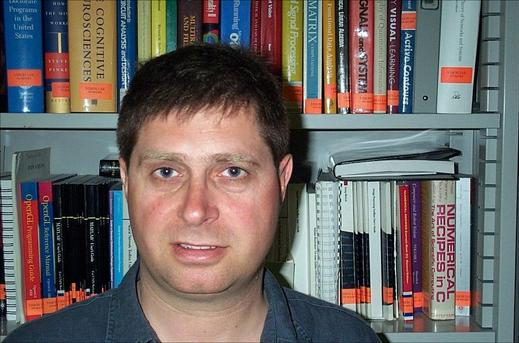

In [2]:
# Find the k most likely matching labels for a given query image under resnet output.

from utils.query_input_processor import get_query_image

image = get_query_image(IMAGE_INPUT)

print("Input image: ", IMAGE_INPUT)
display(image)

In [3]:
# Since RESNET50's output labels do not match Caltech101's output labels, we have
# to use a similar strategy to task 2a in order to find most similar labels. The
# resnet output vector for the dataset was extracted during task 0a.

from feature_models.resnet import ResNetExtractor
vector = ResNetExtractor(image).get_output_vector()

In [4]:
# Load representative label vectors in the resnet output feature space.

from utils.database_utils import retrieve

rep_label_vectors = retrieve(f'rep_label_resnet_output.pt')

In [5]:
# Convert representative label vectors to feature vectors for usage with distance utils.
# We take care not to use the key of this dictionary as IMG_ID.

from utils.vector_utils import rep_label_vectors_to_feature_vectors
rep_feature_vectors = rep_label_vectors_to_feature_vectors(rep_label_vectors)

from utils.distance_utils import get_distance_fn, top_k_unique_label_distance_ranker
distances = top_k_unique_label_distance_ranker(K, vector, rep_feature_vectors, get_distance_fn("resnet_output"))

print("\nK =", K, " most similar labels by resnet_output feature space using distance: ", get_distance_fn("resnet_output").__name__)

for i in range(len(distances)):
    distance, dummy_img_id, label = distances[i]

    print(str(i + 1) + ".", "\tLabel: \t", label, "\t\tDistance: ", distance)




K = 5  most similar labels by resnet_output feature space using distance:  cosine
1. 	Label: 	 Faces 		Distance:  0.18435215950012207
2. 	Label: 	 Faces_easy 		Distance:  0.30128294229507446
3. 	Label: 	 sea_horse 		Distance:  0.7404291927814484
4. 	Label: 	 beaver 		Distance:  0.7429356873035431
5. 	Label: 	 ibis 		Distance:  0.7646322548389435
